# 03 — EDA: a demonstrated sampling-rate limitation, then WESAD chest EDA

**Goal.** Exercise Lamina's EDA pipeline (`eda-clean`, `eda-decompose`,
`eda-peaks` bridge ops) on real wearable EDA and document a confirmed
sampling-rate limitation along the way.

**Part A — Wearable Exam Stress (Empatica E4, EDA @ 4 Hz).**
[Dataset](https://physionet.org/content/wearable-exam-stress/) (ODC-BY 1.0),
subject S1, "Final" exam session. The E4 wrist EDA is sampled at 4 Hz — and
Lamina's `eda_clean` **fails** there: it hardcodes a 5 Hz low-pass cutoff,
which is above the 2 Hz Nyquist frequency at fs = 4 Hz. This is confirmed
bug candidate **BUG-A03** (`validation/results/autonomic/bug-candidates.md`),
which blocks *all* Empatica E4 EDA. We demonstrate the exact error.

**Part B — WESAD (chest RespiBAN, EDA @ 700 Hz).**
[Dataset](https://ubicomp.eti.uni-siegen.de/home/datasets/icmi18/) (MIT),
subject S2. Chest EDA at 700 Hz satisfies the cutoff constraint, so the full
pipeline runs: clean → tonic/phasic decomposition → SCR event detection on a
4-minute baseline window (plus a stress-window contrast). No SCR ground truth
exists — these are *structural* results (event counts/rates), labelled as
such.

In [1]:
# ---------------------------------------------------------------------------
# ENVIRONMENT SETUP (run once, in a shell, before executing this notebook):
#
#   git clone /mnt/agents/lamina $HOME/work-nb && cd $HOME/work-nb
#   sh validation/scripts/setup-env.sh $HOME/work-nb     # Rust + Python deps + builds lamina_bridge
#   pip install jupyter nbconvert nbformat               # notebook tooling
#
# DATA FETCH (cached under $HOME/data, never committed to the repo):
#
#   # A) Wearable Exam Stress, S1 Final EDA (small direct CSV):
#   curl -o $HOME/data/exam-stress/S1_Final_EDA.csv \
#     https://physionet.org/files/wearable-exam-stress/1.0.0/data/S1/Final/EDA.csv
#
#   # B) WESAD S2 pickle — HTTP range-request extraction from the 2.25 GB
#   #    sciebo zip (no full download; ~4 min). Uses the adapter's downloader:
#   python -c "
#   import sys; sys.path.insert(0, '<repo>')
#   from validation.datasets.autonomic import WesadAdapter
#   from pathlib import Path
#   WesadAdapter()._ensure_subject_pkl('S2', Path('$HOME/data/wesad'))"
#
# Execute:  jupyter nbconvert --execute --inplace 03_eda_wesad.ipynb
# ---------------------------------------------------------------------------

In [2]:
import os
import sys
from pathlib import Path

# Locate the repository root (directory containing validation/SPEC.md) and put
# it on sys.path so `import validation...` resolves regardless of the notebook
# kernel's working directory.
REPO_ROOT = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "validation" / "SPEC.md").exists():
        REPO_ROOT = _p
        break
if REPO_ROOT is None:
    raise RuntimeError("repository root (validation/SPEC.md) not found; "
                       "run this notebook from inside the lamina checkout")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = Path(os.environ.get("LAMINA_NB_DATA", Path.home() / "data"))
print(f"repo root: {REPO_ROOT}")
print(f"data cache: {DATA_ROOT}")

import numpy as np
import matplotlib.pyplot as plt

from validation.bridge import LaminaBridge, LaminaBridgeError
from validation.datasets.autonomic import _parse_e4_csv, _longest_run

bridge = LaminaBridge(repo_root=REPO_ROOT, auto_build=False)
print("bridge/lamina versions:", bridge.version())

repo root: /home/kimi/work-nb
data cache: /home/kimi/data


bridge/lamina versions: {'bridge_version': '0.1.0', 'lamina_version': '0.1.0'}


## Part A — E4 wrist EDA @ 4 Hz: the pipeline refuses to run

Empatica E4 exports store the epoch start time in row 1 and the sampling rate
in row 2 (`_parse_e4_csv` from the Stage-2 autonomic adapter). The Final exam
session is ~6.5 h of EDA at 4 Hz; we take the first 5 minutes — plenty to
exercise the pipeline.

In [3]:
eda_csv = DATA_ROOT / "exam-stress" / "S1_Final_EDA.csv"
epoch, fs_e4, eda_e4 = _parse_e4_csv(eda_csv)
seg = eda_e4[: int(300 * fs_e4)]
print(f"S1 Final EDA: {len(eda_e4)} samples @ {fs_e4:.0f} Hz "
      f"= {len(eda_e4)/fs_e4/60:.0f} min; using first 300 s")

try:
    bridge.eda_clean(seg, fs_e4)
    print("UNEXPECTED: eda_clean succeeded at 4 Hz")
except LaminaBridgeError as exc:
    print(f"eda-clean FAILED as expected (BUG-A03)\n"
          f"  error kind : {exc.kind}\n"
          f"  message    : {exc}")

S1 Final EDA: 93582 samples @ 4 Hz = 390 min; using first 300 s
eda-clean FAILED as expected (BUG-A03)
  error kind : lamina_error
  message    : bridge op 'eda-clean' failed [lamina_error]: Invalid cutoff frequency: Cutoff frequency (5) must be strictly less than Nyquist frequency (2)


**Demonstrated limitation (BUG-A03, confirmed).** `eda_clean` hardcodes a
5 Hz low-pass cutoff; at fs = 4 Hz the Nyquist frequency is 2 Hz, so filter
design fails with the exact error above. `eda_peaks` fails identically (it
cleans internally). The consequence: **no Empatica E4 EDA (always 4 Hz) can
be processed by Lamina's EDA cleaning/peak pipeline at its native rate** —
this blocked both wearable-exam-stress and big-ideas EDA in the Stage-2
autonomic validation.

Note the asymmetry: `eda-decompose` does *not* fail at 4 Hz (its tonic
low-pass cutoff is below Nyquist), which is why the bug is localized to the
hardcoded 5 Hz cleaning filter.

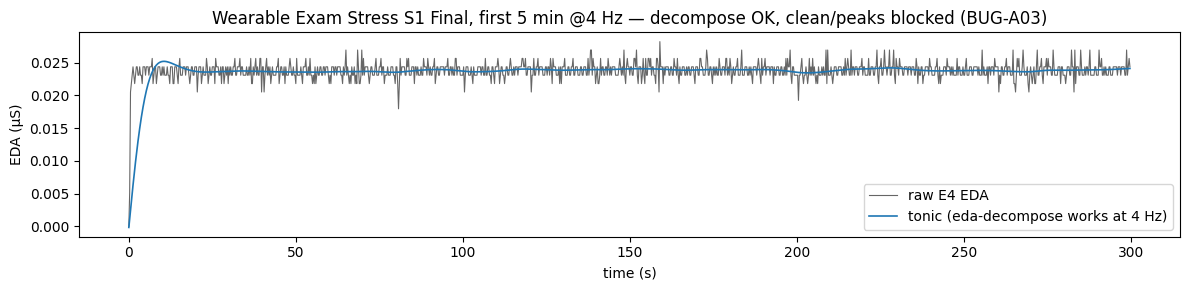

In [4]:
dec4 = bridge.eda_decompose(seg, fs_e4)
t4 = np.arange(len(seg)) / fs_e4
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t4, seg, lw=0.8, color="0.4", label="raw E4 EDA")
ax.plot(t4, dec4["tonic"], lw=1.2, color="tab:blue", label="tonic (eda-decompose works at 4 Hz)")
ax.set_xlabel("time (s)"); ax.set_ylabel("EDA (µS)"); ax.legend()
ax.set_title("Wearable Exam Stress S1 Final, first 5 min @4 Hz — decompose OK, clean/peaks blocked (BUG-A03)")
plt.tight_layout(); plt.show()

## Part B — WESAD S2 chest EDA @ 700 Hz: full pipeline

WESAD subject S2, chest RespiBAN EDA. Following the Stage-2 adapter
(`validation/datasets/autonomic.py::WesadAdapter`): locate the longest
contiguous run of the condition label (1 = baseline) and take the middle
4-minute window. WESAD labels: 0=transient, 1=baseline, 2=stress,
3=amusement, 4=meditation.

In [5]:
import pickle

pkl_path = DATA_ROOT / "wesad" / "S2.pkl"
with open(pkl_path, "rb") as fh:
    s2 = pickle.load(fh, encoding="latin1")

FS_CHEST = 700.0
labels = np.asarray(s2["label"]).ravel()
eda_chest = np.asarray(s2["signal"]["chest"]["EDA"], dtype=float).ravel()
print(f"S2 chest EDA: {len(eda_chest)} samples @ {FS_CHEST:.0f} Hz "
      f"= {len(eda_chest)/FS_CHEST/60:.1f} min; labels {np.unique(labels)}")

def condition_window(cond_code, window_sec=240.0):
    run = _longest_run(labels, cond_code)
    mid = (run[0] + run[1]) // 2
    half = int(window_sec * FS_CHEST) // 2
    i0 = max(run[0], mid - half)
    i1 = min(run[1], i0 + int(window_sec * FS_CHEST))
    return eda_chest[i0:i1], i0 / FS_CHEST

eda_base, base_t0 = condition_window(1)
del s2  # free the ~1 GB pickle payload
print(f"baseline window: {len(eda_base)} samples "
      f"({len(eda_base)/FS_CHEST:.0f} s), starting at t = {base_t0/60:.1f} min")

S2 chest EDA: 4255300 samples @ 700 Hz = 101.3 min; labels [0 1 2 3 4 6 7]
baseline window: 168000 samples (240 s), starting at t = 12.6 min


### Clean → decompose → SCR events (baseline)

SCR events in 4-min baseline: 0 (0.00/min — structural metric, no ground truth)


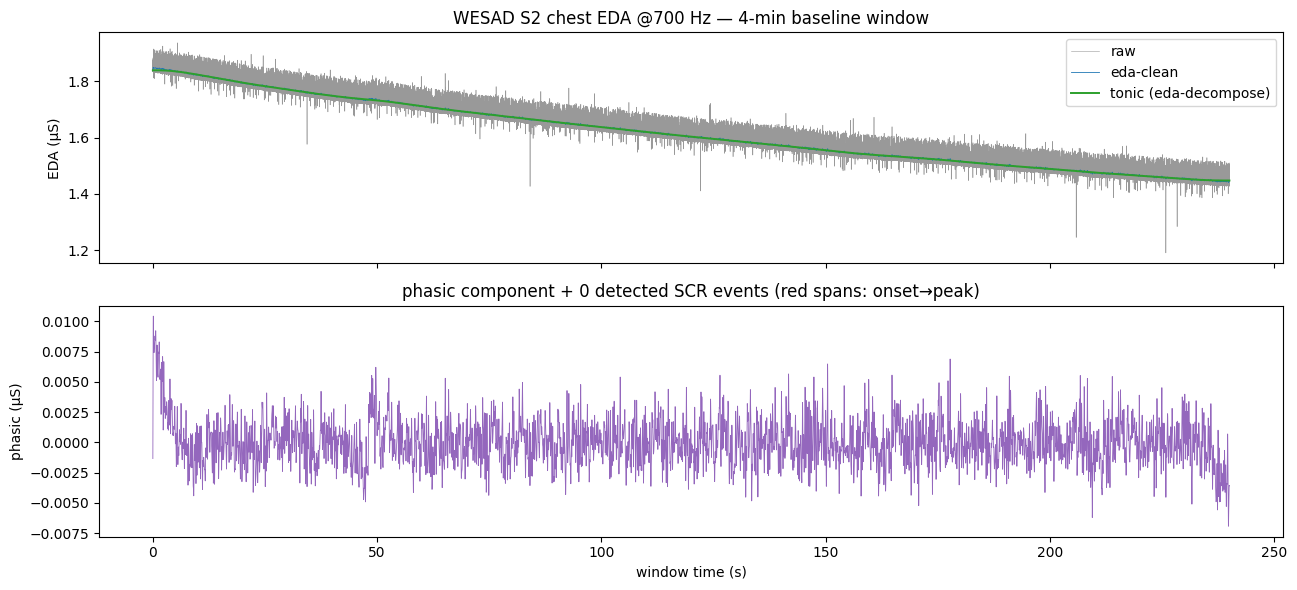

In [6]:
cleaned = bridge.eda_clean(eda_base, FS_CHEST)
dec = bridge.eda_decompose(cleaned, FS_CHEST)
ev = bridge.eda_peaks(eda_base, FS_CHEST)
events = ev["events"]
print(f"SCR events in 4-min baseline: {ev['count']} "
      f"({ev['count']/4.0:.2f}/min — structural metric, no ground truth)")

t = np.arange(len(eda_base)) / FS_CHEST
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(t, eda_base, lw=0.4, color="0.6", label="raw")
ax[0].plot(t, cleaned, lw=0.6, color="tab:blue", label="eda-clean")
ax[0].plot(t, dec["tonic"], lw=1.4, color="tab:green", label="tonic (eda-decompose)")
ax[0].set_ylabel("EDA (µS)"); ax[0].legend(loc="upper right")
ax[0].set_title("WESAD S2 chest EDA @700 Hz — 4-min baseline window")
ax[1].plot(t, dec["phasic"], lw=0.6, color="tab:purple", label="phasic")
for e in events:
    ax[1].axvspan(e["onset_index"]/FS_CHEST, e["peak_index"]/FS_CHEST,
                  color="tab:red", alpha=0.3)
    ax[1].plot(e["peak_index"]/FS_CHEST, dec["phasic"][e["peak_index"]],
               "v", color="tab:red")
ax[1].set_ylabel("phasic (µS)"); ax[1].set_xlabel("window time (s)")
ax[1].set_title(f"phasic component + {ev['count']} detected SCR events (red spans: onset→peak)")
plt.tight_layout(); plt.show()

### Contrast: stress window

The known-groups expectation is baseline < stress SCR rate. Stage-2 measured
S2 baseline = 0.0/min vs stress = 1.0/min (`metrics_extra.csv`); we recompute
both here. (For most subjects the gap is larger — group medians 0.5 vs
8.5/min — and S3's baseline is a documented outlier, BUG-A02.)

SCR rate — baseline: 0.00/min, stress: 1.00/min  (structural)


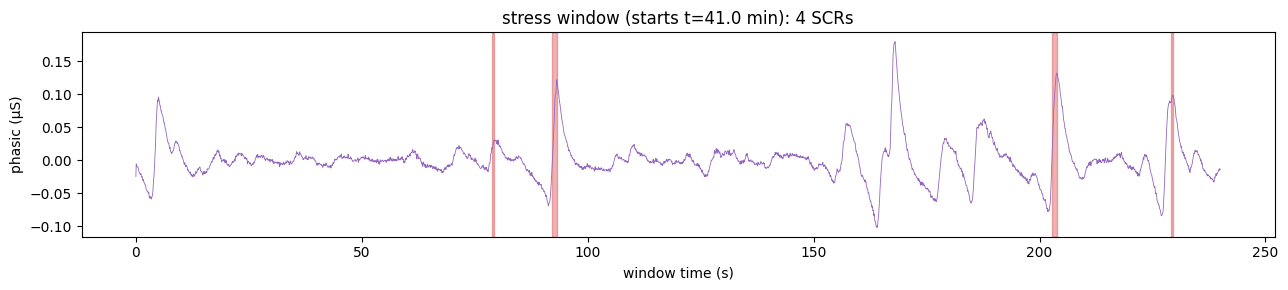

,amplitude,onset_index,peak_index,rise_time_sec
0,0.014274,55228,55517,0.412857
1,0.122353,64521,65210,0.984286
2,0.132212,141910,142688,1.111429
3,0.010763,160381,160651,0.385714


In [7]:
eda_stress, stress_t0 = condition_window(2)
ev_stress = bridge.eda_peaks(eda_stress, FS_CHEST)
dec_stress = bridge.eda_decompose(bridge.eda_clean(eda_stress, FS_CHEST), FS_CHEST)
print(f"SCR rate — baseline: {ev['count']/4.0:.2f}/min, "
      f"stress: {ev_stress['count']/4.0:.2f}/min  (structural)")

t = np.arange(len(eda_stress)) / FS_CHEST
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(t, dec_stress["phasic"], lw=0.6, color="tab:purple")
for e in ev_stress["events"]:
    ax.axvspan(e["onset_index"]/FS_CHEST, e["peak_index"]/FS_CHEST,
               color="tab:red", alpha=0.35)
ax.set_xlabel("window time (s)"); ax.set_ylabel("phasic (µS)")
ax.set_title(f"stress window (starts t={stress_t0/60:.1f} min): "
             f"{ev_stress['count']} SCRs")
plt.tight_layout(); plt.show()

if ev_stress["events"]:
    import pandas as pd
    display(pd.DataFrame(ev_stress["events"]))

## Findings

- **BUG-A03 demonstrated end-to-end**: `eda-clean`/`eda-peaks` fail on real
  Empatica E4 EDA @ 4 Hz with `Invalid cutoff frequency: Cutoff frequency (5)
  must be strictly less than Nyquist frequency (2)`; `eda-decompose` works at
  the same rate. Any consumer with ≤ 10 Hz EDA must resample before cleaning
  (or the cutoff must become fs-aware in Lamina — a Lamina-side decision, not
  made here).
- At 700 Hz (WESAD chest) the full pipeline runs cleanly: tonic/phasic
  decomposition is plausible (slow drift in tonic, transient SCRs in phasic)
  and the detected SCR rates reproduce the Stage-2 known-groups direction
  (baseline ≤ stress).
- SCR counts are **structural metrics** — WESAD ships no SCR ground truth, so
  no accuracy claim is made for event detection.

*Environment*: bridge/lamina versions in the setup cell; exam-stress CSV via
physionet.org/files; WESAD S2 via HTTP range extraction from the sciebo zip.